In [1]:
using DifferentialEquations, LinearAlgebra, Plots, QuantumOptics

In [2]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)')
#ρ_0 /=tr(ρ_0)

4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [3]:
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Ω = p[1]
    Δ = p[2]
    γ_D = p[3]
    γ_d = p[4]

    #ρ /= tr(ρ)
    
    #Hamiltonian
    H = Ω/2 .* kron(I,σ_x) + Δ .* kron(I,n) - Δ .* kron(n,n)
    l_decay = γ_D .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    l_dephase = γ_d .* (kron(I,σ_z) * ρ * kron(I,σ_z) - ρ)

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
    print(dρ)

end

master_eqn (generic function with 1 method)

In [4]:
tspan = (0.0,2.0)   #time span
p = [20,2000,1,20]  #[Ω,Δ,γ_Decay,γ_dephase]

#solving diff master_eqn
eqn = ODEProblem(master_eqn,ρ_0,tspan,p)
sol = solve(eqn,Tsit5(),saveat = 0.01)
println(sol[end])

ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 10.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 10.0im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 10.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 10.0im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im -0.00014128007616114838 + 0.0im 0.0 + 9.999713907845774im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 9.999713907845774im 0.00014128007616114838 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im -0.002274609226194489 + 0.0im 0.0 + 9.995393916316957im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 9.995393916316957im 0.002274609226194489 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0

In [5]:
ss_prblm = SteadyStateProblem(eqn)
ss_soln = solve(ss_prblm,DynamicSS(Tsit5()))

ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 10.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 10.0im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 10.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 10.0im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 10.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 10.0im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im -0.001400211447894154 + 0.0im 0.0 + 9.997164571818015im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 9.997164571818015im 0.001400211447894154 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im

retcode: Success
u: 4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im      0.0+0.0im            0.0+0.0im
 0.0+0.0im  0.0+0.0im      0.0+0.0im            0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.54597+0.0im            0.0+0.0227015im
 0.0+0.0im  0.0+0.0im      0.0-0.0227015im  0.45403+0.0im

In [6]:
for (t, ρ) in zip(sol.t, sol.u)
    println("Time: $t, Trace: $(tr(ρ))")
end

Time: 0.0, Trace: 1.0 + 0.0im
Time: 0.01, Trace: 0.9999999999999999 + 0.0im
Time: 0.02, Trace: 1.0 + 0.0im
Time: 0.03, Trace: 0.9999999999999999 + 0.0im
Time: 0.04, Trace: 0.9999999999999999 + 0.0im
Time: 0.05, Trace: 0.9999999999999999 + 0.0im
Time: 0.06, Trace: 0.9999999999999999 + 0.0im
Time: 0.07, Trace: 0.9999999999999999 + 0.0im
Time: 0.08, Trace: 0.9999999999999999 + 0.0im
Time: 0.09, Trace: 1.0 + 0.0im
Time: 0.1, Trace: 1.0 + 0.0im
Time: 0.11, Trace: 0.9999999999999999 + 0.0im
Time: 0.12, Trace: 1.0 + 0.0im
Time: 0.13, Trace: 1.0 + 0.0im
Time: 0.14, Trace: 1.0 + 0.0im
Time: 0.15, Trace: 1.0 + 0.0im
Time: 0.16, Trace: 1.0 + 0.0im
Time: 0.17, Trace: 1.0 + 0.0im
Time: 0.18, Trace: 1.0 + 0.0im
Time: 0.19, Trace: 1.0 + 0.0im
Time: 0.2, Trace: 1.0 + 0.0im
Time: 0.21, Trace: 1.0 + 0.0im
Time: 0.22, Trace: 1.0 + 0.0im
Time: 0.23, Trace: 1.0 + 0.0im
Time: 0.24, Trace: 1.0 + 0.0im
Time: 0.25, Trace: 1.0 + 0.0im
Time: 0.26, Trace: 1.0 + 0.0im
Time: 0.27, Trace: 1.0 + 0.0im
Time: 0.28, Tra

In [7]:
ψ_ideal = α*kron(r,r) + β*kron(g,g)

fidelities = []
time = []
for (t,ρ) in zip(sol.t,sol.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

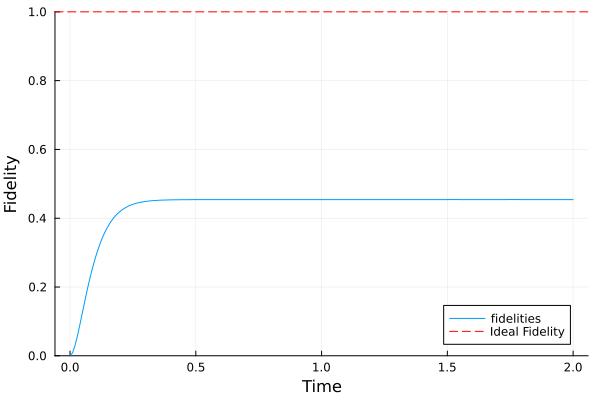

In [8]:
plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1))
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

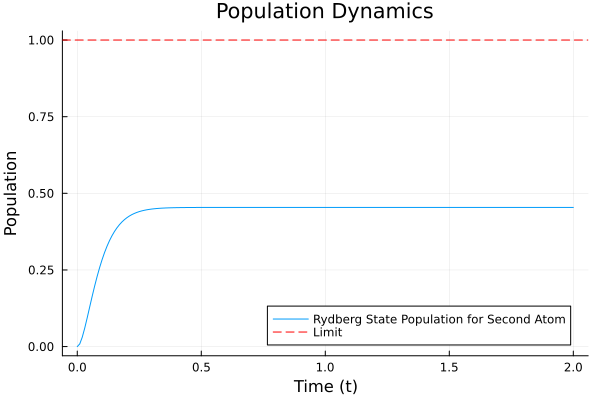

In [11]:
# Example of extracting populations from the solution
rydberg_populations = []

for ρ in sol.u
    # Population of the second atom in Rydberg state is the sum of the probabilities
    # of |gr⟩ (index 2) and |rr⟩ (index 4) states
    population_rg = ρ[2, 2] + ρ[4, 4]
    push!(rydberg_populations, population_rg)
end

# Plotting the Rydberg state population over time
plot(sol.t, rydberg_populations, label="Rydberg State Population for Second Atom", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label="Limit")


In [10]:
    # ρ = ρ_0
    
    
    # σ_x = [0 1; 1 0]
    # n = [0 0; 0 1]
    # I = [1 0; 0 1]
    # σ_minus = [0 1; 0 0]
    # σ_plus = [0 0; 1 0]
    # σ_z = [1 0; 0 -1]

    # #parameters
    # Ω = 20
    # Δ = 2000
    # γ_D = 1
    # γ_d = 20

    # #ρ /= tr(ρ)
    
    # #Hamiltonian
    # H = Ω/2 .* kron(I,σ_x) + Δ .* kron(I,n) - Δ .* kron(n,n)
    # l_decay = γ_D .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    # l_dephase = γ_d .* (kron(I,σ_z) * ρ * kron(I,σ_z) - 0.5.*ρ)
 
    # L = -1im .* (H*ρ - ρ*H) + l_decay + l_dephase

